# Lane Detection using OpenCV


## Part 1 : Modifying the code and test in a gei

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def dark_tape_mask(bgr_image, kernel_size=5, clip_limit=2.0, tile_grid_size=(8,8)):
    #Adaptive dark-tape mask using CLAHE on the Y channel.

    # Convert to YCrCb and extract Y channel
    ycrcb = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2YCrCb)
    Y, _, _ = cv2.split(ycrcb)

    # Apply CLAHE (adaptive histogram equalization) to enhance dark tape
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    chan_y = clahe.apply(Y)

    # Simple adaptive threshold: mean - some factor
    mean_y = np.mean(chan_y)
    thresh = max(0, int(mean_y * 0.5))  # dark tape is darker than mean

    # Mask: pixels darker than threshold
    mask = cv2.inRange(chan_y, 0, thresh)

    # Morphology to clean noise
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    return mask



def centerline_from_mask(mask, kernel_size=3):

    # erode to shrink the thick lane
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    eroded = cv2.erode(mask, kernel, iterations=1)
    eroded = cv2.GaussianBlur(eroded, (3, 3), 0)  # soft blur
    
    skel = np.zeros(eroded.shape, np.uint8)

    element = cv2.getStructuringElement(cv2.MORPH_CROSS, (3,3))
    done = False
    
    while not done:
        eroded_temp = cv2.erode(eroded, element)
        temp = cv2.dilate(eroded_temp, element)
        temp = cv2.subtract(eroded, temp)
        skel = cv2.bitwise_or(skel, temp)
        eroded = eroded_temp.copy()
        if cv2.countNonZero(eroded) == 0:
            done = True
    return skel

def prune_by_length(skel, min_length=60):
    # Keep only skeleton components longer than min_length pixels.
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(skel, connectivity=8)
    
    pruned = np.zeros_like(skel)
    for i in range(1, num_labels):
        # Use bounding box aspect ratio as proxy for length
        width = stats[i, cv2.CC_STAT_WIDTH]
        height = stats[i, cv2.CC_STAT_HEIGHT]
        length_proxy = max(width, height)  # longest dimension
        
        if length_proxy >= min_length:
            pruned[labels == i] = 255
    
    return pruned



def polynomial_lane_fit(edges, min_points=300):
    ys, xs = np.nonzero(edges > 0)

    if len(xs) < min_points:
        return None, None

    coeffs = np.polyfit(ys, xs, 1)
    return coeffs, ys

# Remove irrelevant segments of the image and retain only the lane portion
def roi_on_mask(mask, roi_top_ratio=0.55, roi_bottom_ratio=0.05):
    # mask: single-channel (uint8) 0/255
    h, w = mask.shape[:2]
    roi_mask = np.zeros_like(mask)
    roi_top = int(h * roi_top_ratio)
    roi_bottom = int(h * (1 - roi_bottom_ratio))
    cv2.rectangle(roi_mask, (0, roi_top), (w, roi_bottom), 255, -1)
    return cv2.bitwise_and(mask, roi_mask)

def split_left_right_edges(edges, min_branch_length=40):
    ys, xs = np.nonzero(edges > 0)
    if len(xs) == 0:
        return (None, None), (None, None)

    h, w = edges.shape[:2]
    x_mid = w / 2.0

    left_mask = xs < x_mid
    right_mask = xs >= x_mid
    
    # Pass shape to longest_branch
    left_y, left_x = longest_branch(ys[left_mask], xs[left_mask], min_branch_length, h, w)
    right_y, right_x = longest_branch(ys[right_mask], xs[right_mask], min_branch_length, h, w)

    return (left_y, left_x), (right_y, right_x)

def longest_branch(ys, xs, min_length, h, w):
    if len(xs) == 0:
        return None, None
    
    ys_clipped = np.clip(ys.astype(int), 0, h-1)
    xs_clipped = np.clip(xs.astype(int), 0, w-1)
    
    temp = np.zeros((h, w), np.uint8)
    temp[ys_clipped, xs_clipped] = 255
    
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(temp, connectivity=8)
    
    if num_labels > 1:
        largest_idx = np.argmax(stats[1:, cv2.CC_STAT_AREA]) + 1
        area = stats[largest_idx, cv2.CC_STAT_AREA]
        if area >= min_length:
            component_mask = (labels == largest_idx)
            comp_ys, comp_xs = np.nonzero(component_mask)
            return comp_ys, comp_xs
    
    return None, None



def polynomial_fit_from_points(ys, xs, min_points=50, min_span=40):
    if xs is None or len(xs) < min_points or (len(ys) > 0 and ys.max() - ys.min() < min_span):
        return None
    # Sort by y
    sort_idx = np.argsort(ys)
    ys_sorted = ys[sort_idx]
    xs_sorted = xs[sort_idx]
    # trim 10% endpoints to remove outliers
    trim = max(1, int(0.1 * len(ys)))
    clean_ys = ys_sorted[trim:-trim]
    clean_xs = xs_sorted[trim:-trim]
    # Polyfit
    coeffs = np.polyfit(clean_ys, clean_xs, 1)
    
    return coeffs



def detect_lanes_dark_tape_no_canny(input_image):
    # color mask and get the skeleton of the lanes
    mask = dark_tape_mask(input_image)
    mask_skel = centerline_from_mask(mask)
    mask_skel = prune_by_length(mask_skel)

    # apply ROI directly on skeleton
    roi_skel = roi_on_mask(mask_skel)

    # split points and fit lines
    (left_y, left_x), (right_y, right_x) = split_left_right_edges(roi_skel)
    
    # Require minimum strength per side or poubelle
    left_strength  = len(left_x) if left_x is not None else 0
    right_strength = len(right_x) if right_x is not None else 0

    left_coeffs  = polynomial_fit_from_points(left_y, left_x) if left_strength  >= 50 else None
    right_coeffs = polynomial_fit_from_points(right_y, right_x) if right_strength >= 50 else None
    
    return left_coeffs, right_coeffs, roi_skel, mask

def draw_lines(image, left_coeffs=None, right_coeffs=None, thickness=8, color=(0, 0, 255), y_min_ratio=0.55):

    line_image = np.zeros_like(image)
    h = image.shape[0]
    y_min = int(h * y_min_ratio)
    y_max = h

    for coeffs in [left_coeffs, right_coeffs]:
        if coeffs is not None:
            b, c = coeffs
            x1 = int(b*y_min + c)
            x2 = int(b*y_max + c)
            cv2.line(line_image, (x1, y_min), (x2, y_max), color, thickness)

    return cv2.addWeighted(image, 0.8, line_image, 1.0, 0.0)





#### Section with the set of images for testing parameter

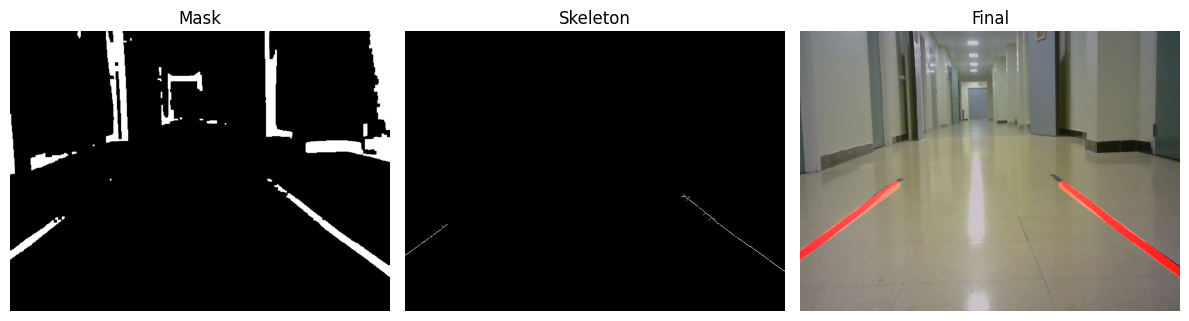

In [13]:
# Image Test 1
inputimage = cv2.imread("test_demo.png")

left_coeffs, right_coeffs, skel_roi, mask = detect_lanes_dark_tape_no_canny(inputimage)

output = draw_lines(inputimage,
                    left_coeffs=left_coeffs,
                    right_coeffs=right_coeffs,
                    thickness=25)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Mask");      plt.imshow(mask, cmap="gray");      plt.axis("off")
plt.subplot(1,3,2); plt.title("Skeleton");  plt.imshow(skel_roi, cmap="gray");  plt.axis("off")
plt.subplot(1,3,3); plt.title("Final");     plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.tight_layout(); plt.show()




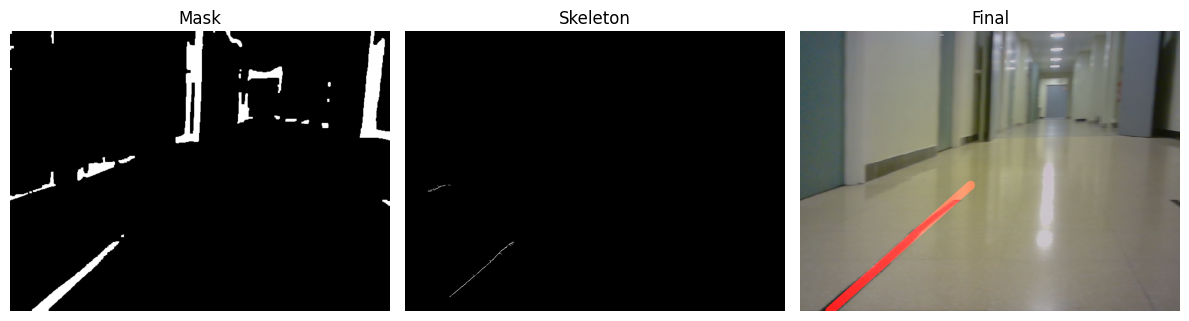

In [14]:
# Image Test 2
inputimage = cv2.imread("test_demo2.png")

left_coeffs, right_coeffs, skel_roi, mask = detect_lanes_dark_tape_no_canny(inputimage)

output = draw_lines(inputimage,
                    left_coeffs=left_coeffs,
                    right_coeffs=right_coeffs,
                    thickness=25)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Mask");      plt.imshow(mask, cmap="gray");      plt.axis("off")
plt.subplot(1,3,2); plt.title("Skeleton");  plt.imshow(skel_roi, cmap="gray");  plt.axis("off")
plt.subplot(1,3,3); plt.title("Final");     plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.tight_layout(); plt.show()


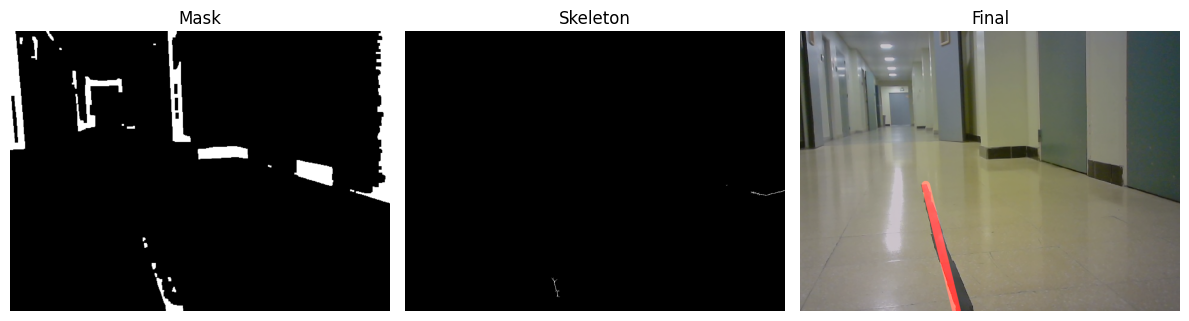

In [15]:
# Image Test 3
inputimage = cv2.imread("test_demo3.png")

left_coeffs, right_coeffs, skel_roi, mask = detect_lanes_dark_tape_no_canny(inputimage)

output = draw_lines(inputimage,
                    left_coeffs=left_coeffs,
                    right_coeffs=right_coeffs,
                    thickness=25)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Mask");      plt.imshow(mask, cmap="gray");      plt.axis("off")
plt.subplot(1,3,2); plt.title("Skeleton");  plt.imshow(skel_roi, cmap="gray");  plt.axis("off")
plt.subplot(1,3,3); plt.title("Final");     plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.tight_layout(); plt.show()




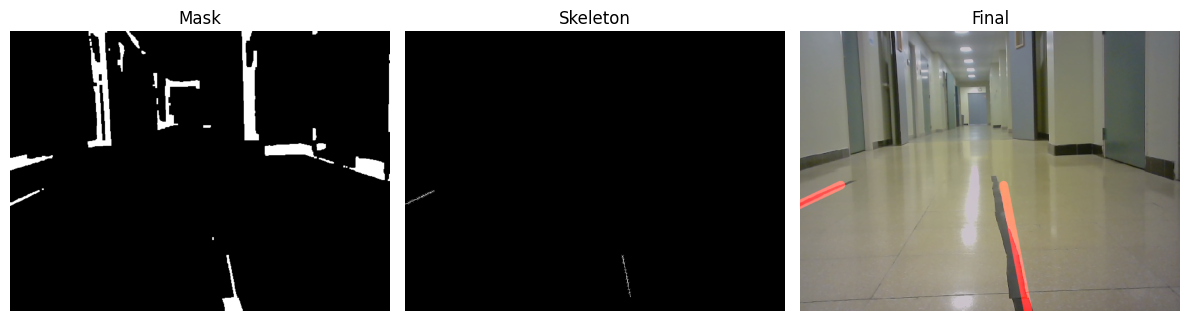

In [16]:
# Image Test 4
inputimage = cv2.imread("test_demo4.png")

left_coeffs, right_coeffs, skel_roi, mask = detect_lanes_dark_tape_no_canny(inputimage)

output = draw_lines(inputimage,
                    left_coeffs=left_coeffs,
                    right_coeffs=right_coeffs,
                    thickness=25)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Mask");      plt.imshow(mask, cmap="gray");      plt.axis("off")
plt.subplot(1,3,2); plt.title("Skeleton");  plt.imshow(skel_roi, cmap="gray");  plt.axis("off")
plt.subplot(1,3,3); plt.title("Final");     plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.tight_layout(); plt.show()



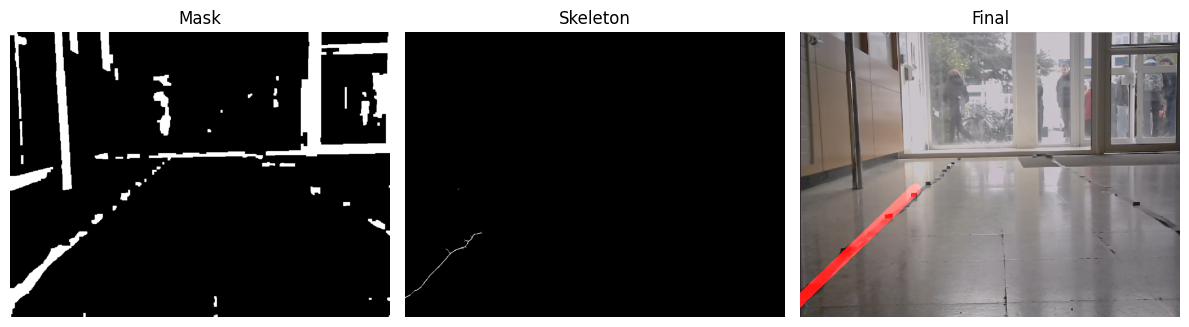

In [17]:
# Image Test 5
inputimage = cv2.imread("test5.png")

left_coeffs, right_coeffs, skel_roi, mask = detect_lanes_dark_tape_no_canny(inputimage)

output = draw_lines(inputimage,
                    left_coeffs=left_coeffs,
                    right_coeffs=right_coeffs,
                    thickness=25)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Mask");      plt.imshow(mask, cmap="gray");      plt.axis("off")
plt.subplot(1,3,2); plt.title("Skeleton");  plt.imshow(skel_roi, cmap="gray");  plt.axis("off")
plt.subplot(1,3,3); plt.title("Final");     plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.tight_layout(); plt.show()



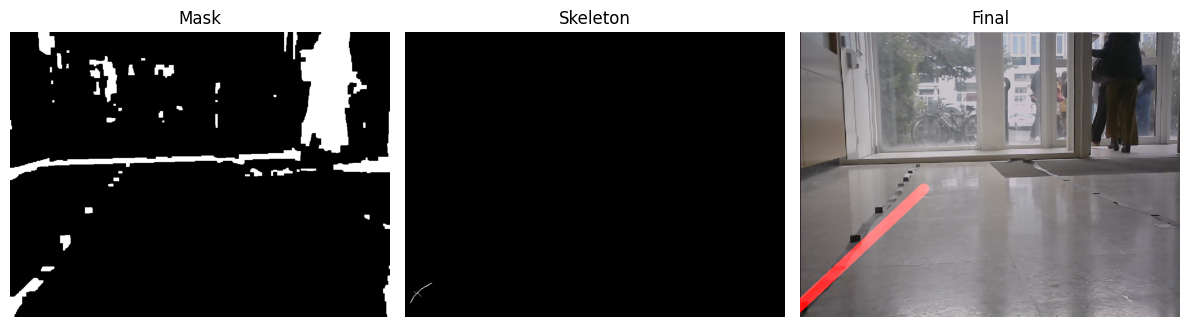

In [18]:
# Image Test 6
inputimage = cv2.imread("test6.png")

left_coeffs, right_coeffs, skel_roi, mask = detect_lanes_dark_tape_no_canny(inputimage)

output = draw_lines(inputimage,
                    left_coeffs=left_coeffs,
                    right_coeffs=right_coeffs,
                    thickness=25)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Mask");      plt.imshow(mask, cmap="gray");      plt.axis("off")
plt.subplot(1,3,2); plt.title("Skeleton");  plt.imshow(skel_roi, cmap="gray");  plt.axis("off")
plt.subplot(1,3,3); plt.title("Final");     plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.tight_layout(); plt.show()



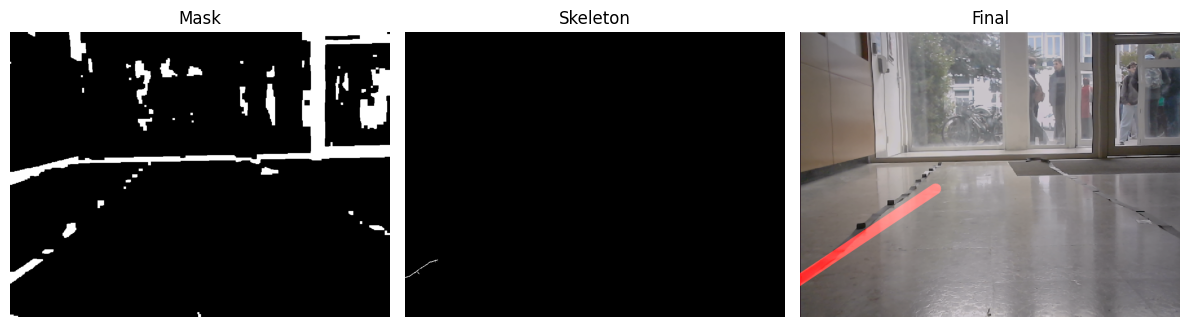

In [19]:
# Image Test 7
inputimage = cv2.imread("test7.png")

left_coeffs, right_coeffs, skel_roi, mask = detect_lanes_dark_tape_no_canny(inputimage)

output = draw_lines(inputimage,
                    left_coeffs=left_coeffs,
                    right_coeffs=right_coeffs,
                    thickness=25)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Mask");      plt.imshow(mask, cmap="gray");      plt.axis("off")
plt.subplot(1,3,2); plt.title("Skeleton");  plt.imshow(skel_roi, cmap="gray");  plt.axis("off")
plt.subplot(1,3,3); plt.title("Final");     plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.tight_layout(); plt.show()

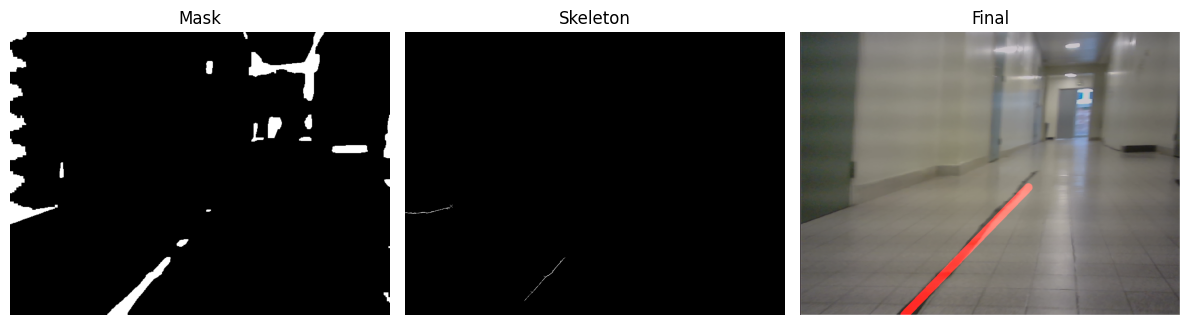

In [20]:
# Image Test 8
inputimage = cv2.imread("test8.png")

left_coeffs, right_coeffs, skel_roi, mask = detect_lanes_dark_tape_no_canny(inputimage)

output = draw_lines(inputimage,
                    left_coeffs=left_coeffs,
                    right_coeffs=right_coeffs,
                    thickness=25)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Mask");      plt.imshow(mask, cmap="gray");      plt.axis("off")
plt.subplot(1,3,2); plt.title("Skeleton");  plt.imshow(skel_roi, cmap="gray");  plt.axis("off")
plt.subplot(1,3,3); plt.title("Final");     plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.tight_layout(); plt.show()

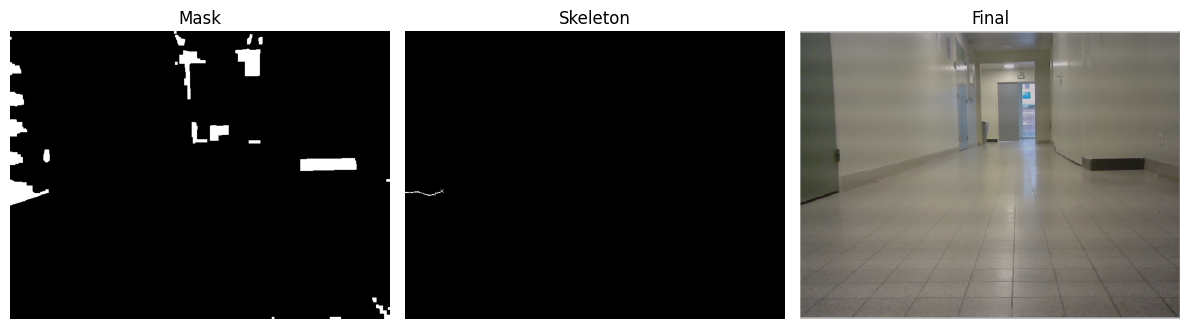

In [21]:
# Image Test 9
inputimage = cv2.imread("test12.png")

left_coeffs, right_coeffs, skel_roi, mask = detect_lanes_dark_tape_no_canny(inputimage)

output = draw_lines(inputimage,
                    left_coeffs=left_coeffs,
                    right_coeffs=right_coeffs,
                    thickness=25)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Mask");      plt.imshow(mask, cmap="gray");      plt.axis("off")
plt.subplot(1,3,2); plt.title("Skeleton");  plt.imshow(skel_roi, cmap="gray");  plt.axis("off")
plt.subplot(1,3,3); plt.title("Final");     plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.tight_layout(); plt.show()

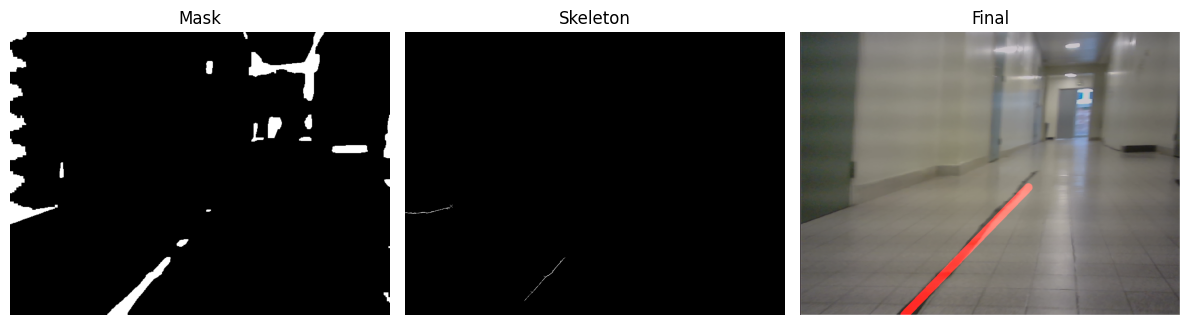

In [22]:
# Image Test 10
inputimage = cv2.imread("test10.png")

left_coeffs, right_coeffs, skel_roi, mask = detect_lanes_dark_tape_no_canny(inputimage)

output = draw_lines(inputimage,
                    left_coeffs=left_coeffs,
                    right_coeffs=right_coeffs,
                    thickness=25)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Mask");      plt.imshow(mask, cmap="gray");      plt.axis("off")
plt.subplot(1,3,2); plt.title("Skeleton");  plt.imshow(skel_roi, cmap="gray");  plt.axis("off")
plt.subplot(1,3,3); plt.title("Final");     plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.tight_layout(); plt.show()